# Task 2 - Decision Trees

Dans ce notebook, nous allons implémenter un modèle d'arbres de décision, un algorithme intuitif et puissant en machine learning supervisé pour les problèmes de classification et de régression.

In [2]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline
#plt.style.use('seaborn')

## 1. Chargement et exploration des données

Pour cette démonstration, nous utiliserons le jeu de données du cancer du sein de Wisconsin, qui est un problème de classification binaire classique.

In [3]:
from sklearn.datasets import load_breast_cancer

# Chargement des données du cancer du sein de Wisconsin
breast_cancer = load_breast_cancer()

# Création d'un DataFrame pandas
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Exploration des données
print("Shape of dataset:", df.shape)
print("\nInfo of dataset:")
df.info()

Shape of dataset: (569, 31)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

In [5]:
# Statistiques descriptives
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Variable cible: target

Distribution des classes:
target
1    357
0    212
Name: count, dtype: int64


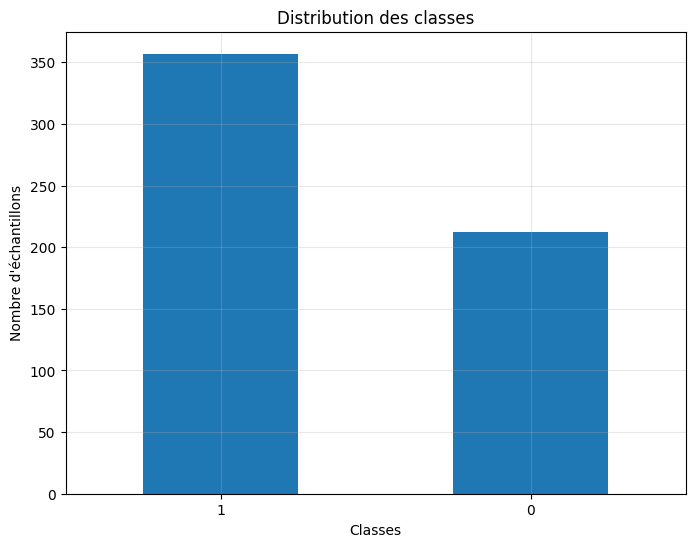

In [6]:
# Vérification de la distribution des classes (variable cible)
target_column = df.columns[-1]
print(f"Variable cible: {target_column}")
print("\nDistribution des classes:")
print(df[target_column].value_counts())

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
df[target_column].value_counts().plot(kind='bar')
plt.title('Distribution des classes')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

## 2. Prétraitement des données

Séparation des caractéristiques (features) et de la variable cible.

In [7]:
# Séparation des caractéristiques (features) et de la variable cible
X = df.iloc[:, :-1]  # Toutes les colonnes sauf la dernière
y = df.iloc[:, -1]   # Dernière colonne (variable cible)

print(f"Dimensions des caractéristiques: {X.shape}")
print(f"Dimensions de la variable cible: {y.shape}")

Dimensions des caractéristiques: (569, 30)
Dimensions de la variable cible: (569,)


## 3. Division des données

Division des données en ensembles d'entraînement et de test.

In [8]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (455, 30)
Taille de l'ensemble de test: (114, 30)


## 4. Entraînement du modèle

Création et entraînement du modèle d'arbre de décision.

In [9]:
# Création et entraînement de l'arbre de décision
# Paramètres initiaux
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## 5. Prédiction et évaluation du modèle

Prédiction sur l'ensemble de test et évaluation des performances du modèle.

In [10]:
# Prédiction sur l'ensemble de test
y_pred = dt_classifier.predict(X_test)

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred})
print("Comparaison des valeurs réelles et prédites:")
print(results_df.head(10))

Comparaison des valeurs réelles et prédites:
     Valeurs réelles  Prédictions
256                0            0
428                1            1
501                0            0
363                1            1
564                0            0
464                1            1
358                1            1
343                0            0
516                0            0
567                0            0


In [11]:
# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle: {accuracy:.4f}")

# Rapport de classification détaillé
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

Précision du modèle: 0.9123

Rapport de classification:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



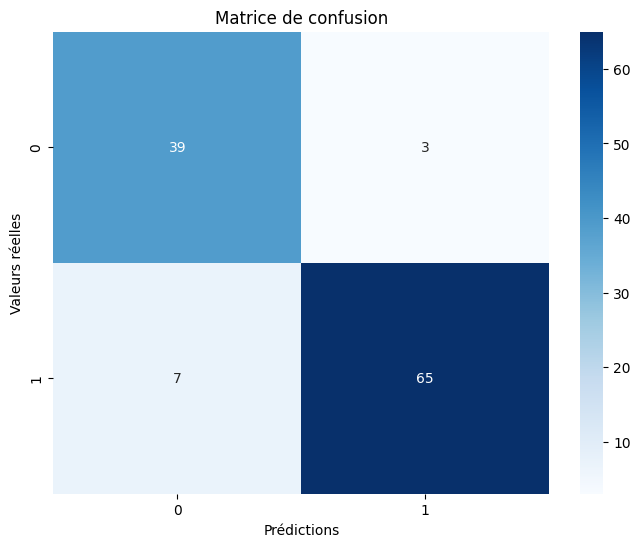

In [12]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

## 6. Visualisation de l'arbre de décision

Visualisation graphique de l'arbre résultant pour interpréter les règles de décision.

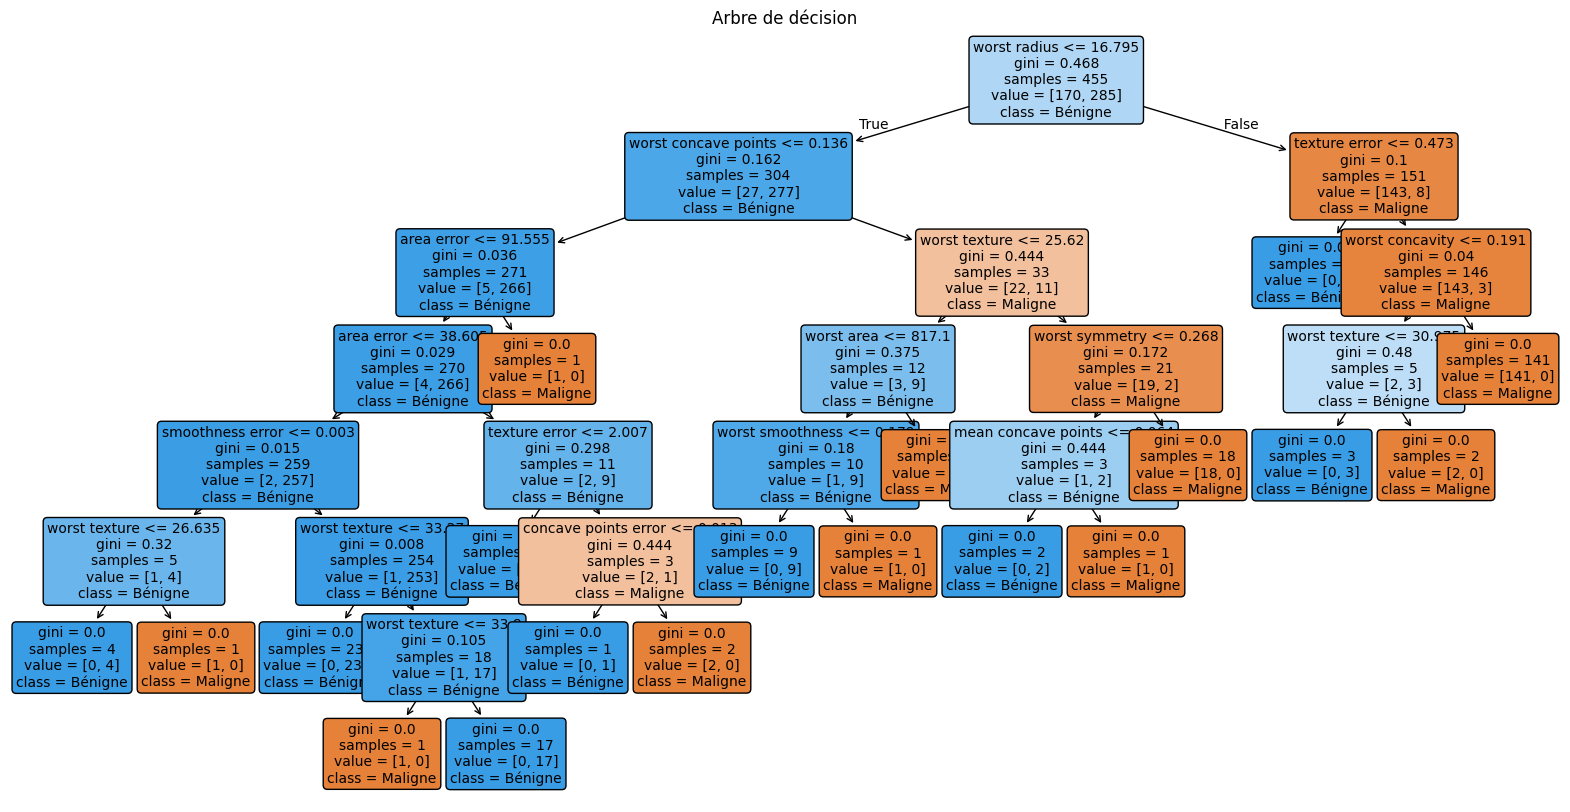

In [13]:
# Visualisation de l'arbre de décision (simplifiée)
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier,
          feature_names=X.columns,
          class_names=['Maligne', 'Bénigne'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Arbre de décision')
plt.show()

## 7. Évaluation de la complexité de l'arbre

Analyse de la profondeur et du nombre de feuilles pour comprendre la complexité du modèle.

In [14]:
# Informations sur l'arbre
print(f"Profondeur de l'arbre: {dt_classifier.get_depth()}")
print(f"Nombre de feuilles: {dt_classifier.get_n_leaves()}")
print(f"Nombre de noeuds: {dt_classifier.tree_.node_count}")

Profondeur de l'arbre: 7
Nombre de feuilles: 19
Nombre de noeuds: 37


## 8. Pruning (élagage) pour éviter le sur-apprentissage

Application de techniques de pruning pour améliorer la généralisation du modèle.

In [15]:
# Création d'un arbre avec contraintes pour éviter le sur-apprentissage
dt_pruned = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,           # Limite la profondeur maximale
    min_samples_split=20,  # Nombre minimum d'échantillons pour diviser un noeud
    min_samples_leaf=10,   # Nombre minimum d'échantillons dans une feuille
    max_features='sqrt'    # Nombre maximum de caractéristiques à considérer pour chaque division
)

# Entraînement du modèle élagué
dt_pruned.fit(X_train, y_train)

# Prédiction avec le modèle élagué
y_pred_pruned = dt_pruned.predict(X_test)

# Évaluation du modèle élagué
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(f"Précision du modèle élagué: {accuracy_pruned:.4f}")
print(f"Précision du modèle original: {accuracy:.4f}")

print("\nRapport de classification du modèle élagué:")
print(classification_report(y_test, y_pred_pruned))

Précision du modèle élagué: 0.9211
Précision du modèle original: 0.9123

Rapport de classification du modèle élagué:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



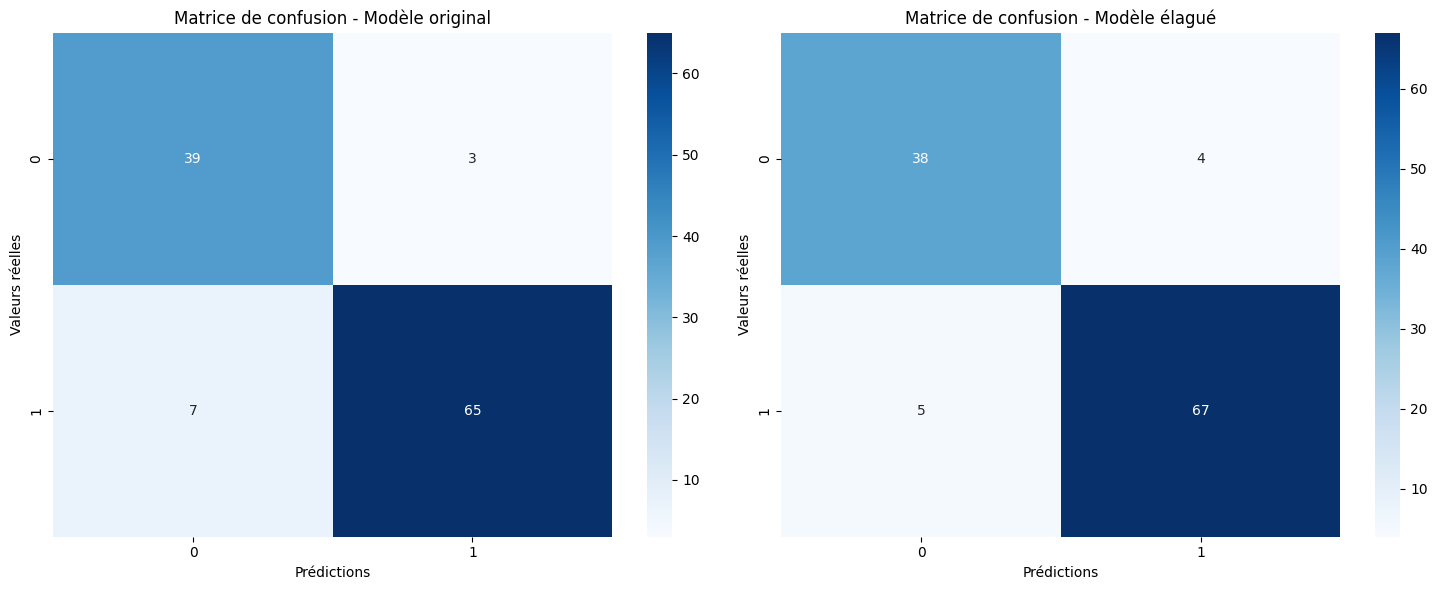

In [16]:
# Comparaison des matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matrice de confusion du modèle original
cm_original = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matrice de confusion - Modèle original')
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Valeurs réelles')

# Matrice de confusion du modèle élagué
cm_pruned = confusion_matrix(y_test, y_pred_pruned)
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matrice de confusion - Modèle élagué')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Valeurs réelles')

plt.tight_layout()
plt.show()

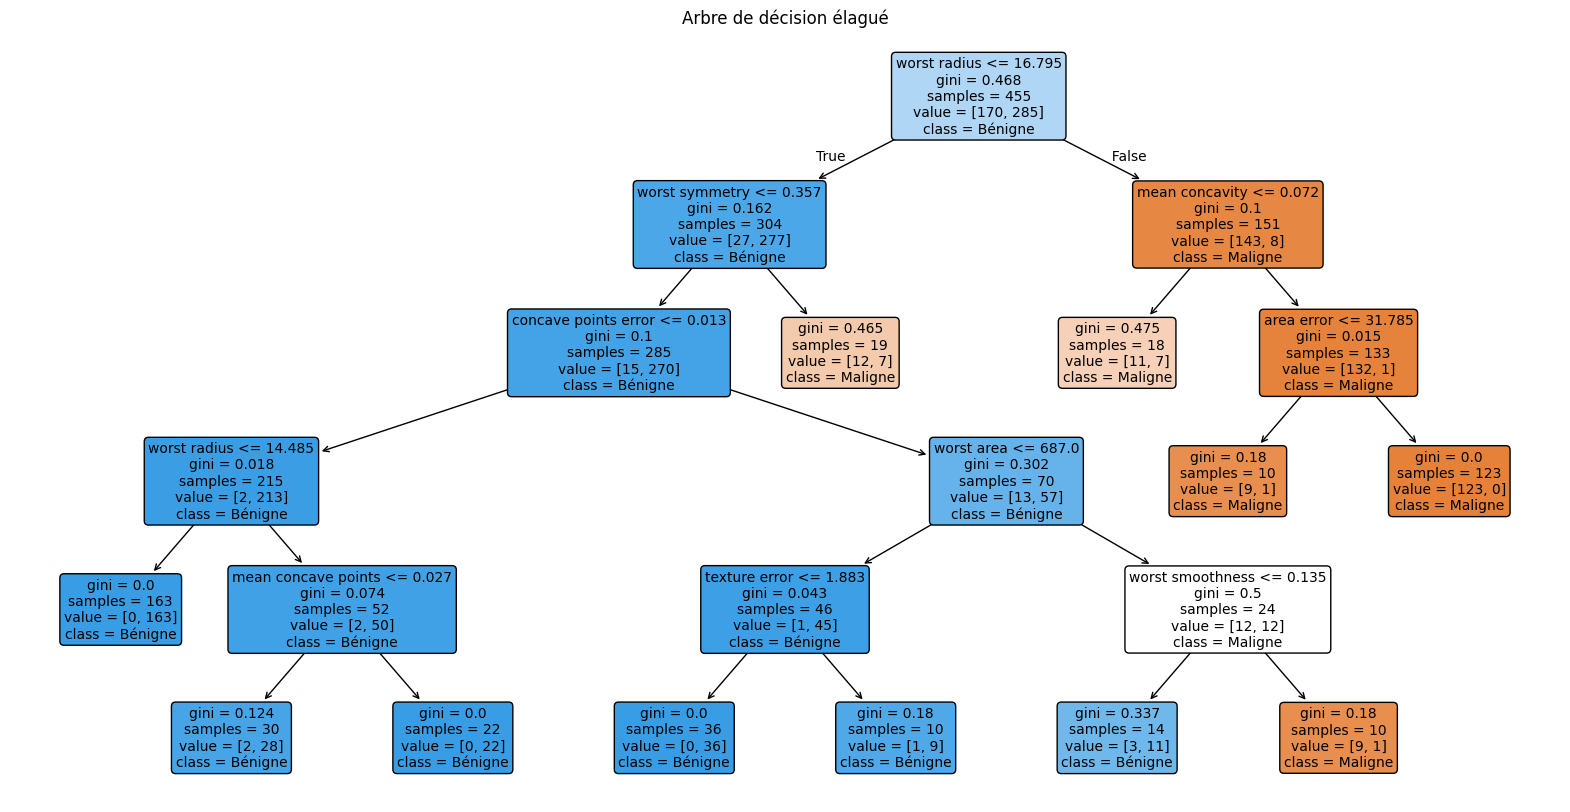

In [17]:
# Visualisation de l'arbre élagué
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned,
          feature_names=X.columns,
          class_names=['Maligne', 'Bénigne'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Arbre de décision élagué')
plt.show()

## 9. Importance des caractéristiques

Analyse de l'importance des différentes caractéristiques dans la prise de décision.

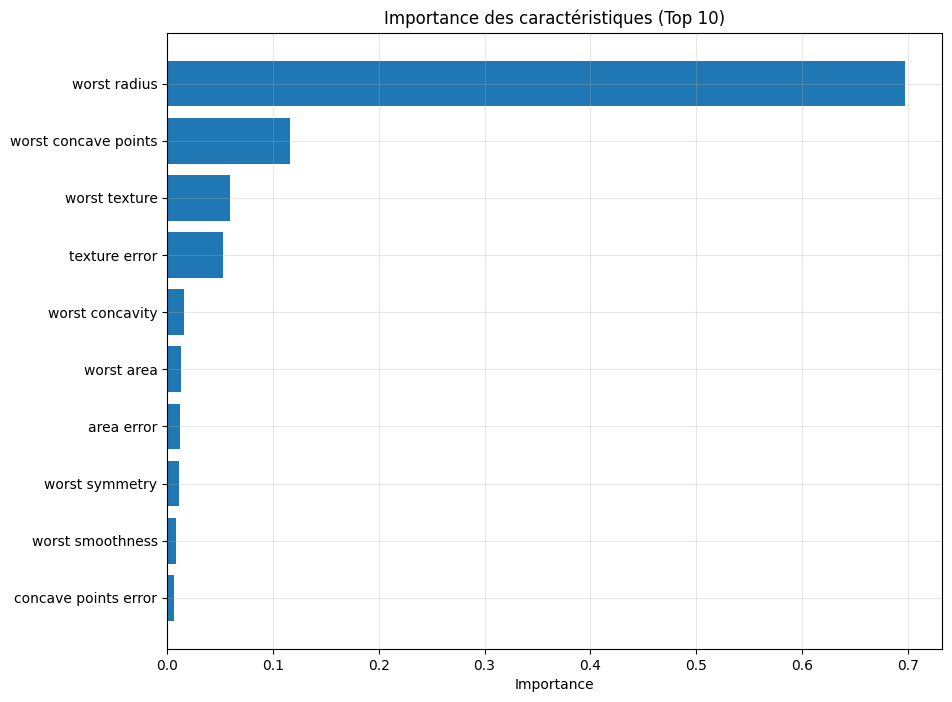

Caractéristiques les plus importantes:
                 Feature  Importance
20          worst radius    0.697811
27  worst concave points    0.116083
21         worst texture    0.058881
11         texture error    0.052661
26       worst concavity    0.016325
23            worst area    0.012678
13            area error    0.012085
28        worst symmetry    0.010733
24      worst smoothness    0.008452
17  concave points error    0.006261


In [18]:
# Importance des caractéristiques
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisation des 10 caractéristiques les plus importantes
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Importance des caractéristiques (Top 10)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("Caractéristiques les plus importantes:")
print(feature_importance.head(10))

## Conclusion

Dans ce notebook, nous avons implémenté un modèle d'arbres de décision :
- Chargement et exploration des données du cancer du sein
- Prétraitement des données
- Division des données en ensembles d'entraînement et de test
- Entraînement du modèle d'arbre de décision
- Évaluation du modèle avec plusieurs métriques
- Visualisation de l'arbre résultant
- Application de techniques de pruning pour éviter le sur-apprentissage
- Analyse de l'importance des caractéristiques

Les arbres de décision sont faciles à interpréter et peuvent gérer à la fois des données numériques et catégorielles sans avoir besoin de beaucoup de prétraitement. Le pruning est essentiel pour éviter le sur-apprentissage et améliorer la généralisation du modèle.